In [ ]:
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import datetime
import os
import pickle
import warnings
warnings.filterwarnings('ignore')

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {tf.config.list_physical_devices("GPU")}')

TensorFlow version: 2.20.0
GPU available: []


In [ ]:
from google.colab import files

print('Silakan upload file Data_Finance_Final.csv')
uploaded = files.upload()

# Load CSV
df = pd.read_csv('Data_Finance_Final.csv')

print(f'\n Data berhasil dimuat!')
print(f'   Shape     : {df.shape}')
display(df.head())


Silakan upload file Data_Finance_Final.csv


Saving Data_Finance_Final.csv to Data_Finance_Final (1).csv

 Data berhasil dimuat!
   Shape     : (968, 16)


,Date,Title,Amount,Type,Category,Account,Year,Month,Day,DayOfWeek,IsWeekend,Month_Name,Is_Income,Amount_Log,Category_Encoded,Account_Encoded
0,2025-07-01,Parkir,15907.28,EXPENSE,Tagihan,Gopay,2025,7,1,1,0,July,0,9.674595,5,2
1,2025-07-01,Iuran Bulanan,12793.08,EXPENSE,Tagihan,BCA,2025,7,1,1,0,July,0,9.456738,5,0
2,2025-07-01,Streaming,13464.10,EXPENSE,Hiburan,Dompet Tunai,2025,7,1,1,0,July,0,9.507856,3,1
3,2025-07-01,Warung Nasi,17475.95,EXPENSE,Makan & Minum,Dompet Tunai,2025,7,1,1,0,July,0,9.768638,4,1
4,2025-07-02,Internet,11967.09,EXPENSE,Tagihan,Gopay,2025,7,2,2,0,July,0,9.389999,5,2


In [ ]:
@tf.keras.utils.register_keras_serializable(package='Custom', name='CustomSparseCategoricalCrossentropy')
class CustomSparseCategoricalCrossentropy(tf.keras.losses.Loss):
    def __init__(self, gamma=1.5, name='custom_sparse_categorical_crossentropy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma
        self.scce = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False, reduction=tf.keras.losses.Reduction.NONE)

    def call(self, y_true, y_pred):
        base_loss = self.scce(y_true, y_pred)
        # Ambil probabilitas tebakan untuk kelas yang benar
        y_true_casted = tf.cast(y_true, tf.int32)

        # Focal weight (semakin yakin model, semakin kecil loss-nya, memaksa fokus ke yang salah/minoritas)
        # Clip y_pred untuk menghindari log 0
        y_pred_safe = tf.clip_by_value(y_pred, 1e-7, 1.0 - 1e-7)
        pt = tf.reduce_max(tf.one_hot(y_true_casted, depth=tf.shape(y_pred)[1]) * y_pred_safe, axis=-1)
        focal_weight = tf.pow(1.0 - pt, self.gamma)

        return tf.reduce_mean(focal_weight * base_loss)

    def get_config(self):
        return {'name': self.name, 'gamma': self.gamma}

@tf.keras.utils.register_keras_serializable(package='Custom', name='CustomForecastingLoss')
class CustomForecastingLoss(tf.keras.losses.Loss):
    def __init__(self, name='custom_forecasting_loss', **kwargs):
        super().__init__(name=name, **kwargs)

    def call(self, y_true, y_pred):
        diff = y_true - y_pred
        abs_diff = tf.abs(diff)
        # Penalti under-prediction yang lebih smooth agar MAE tidak melonjak
        penalty = tf.where(diff > 0, 1.05 * abs_diff, abs_diff)
        return tf.reduce_mean(penalty)

    def get_config(self):
        return {'name': self.name}

class ClassifierTargetCallback(tf.keras.callbacks.Callback):
    def __init__(self, target_accuracy=0.85):
        super().__init__()
        self.target_accuracy = target_accuracy

    def on_epoch_end(self, epoch, logs=None):
        val_acc = (logs or {}).get('val_accuracy')
        if val_acc is not None and val_acc >= self.target_accuracy:
            print(f'\n TARGET TERCAPAI di epoch {epoch + 1}: val_accuracy = {val_acc:.4f}')
            self.model.stop_training = True

class ForecasterTargetCallback(tf.keras.callbacks.Callback):
    def __init__(self, target_mae=0.02):
        super().__init__()
        self.target_mae = target_mae

    def on_epoch_end(self, epoch, logs=None):
        val_mae = (logs or {}).get('val_mae')
        if val_mae is not None and val_mae <= self.target_mae:
            print(f'\n TARGET TERCAPAI di epoch {epoch + 1}: val_mae = {val_mae:.4f}')
            self.model.stop_training = True

In [ ]:
# Split Data sebelum oversampling untuk mencegah data leakage
df_train, df_val = train_test_split(df, test_size=0.2, random_state=42, stratify=df['Category'])

# Oversampling kelas minoritas HANYA pada data training
class_counts = df_train['Category'].value_counts()
minority_classes = class_counts[class_counts < class_counts.max() * 0.5].index

df_minority = df_train[df_train['Category'].isin(minority_classes)].copy()
# Gandakan data minoritas sebanyak 3x di training set
df_train_aug = pd.concat([df_train, df_minority, df_minority, df_minority], ignore_index=True)
df_train_aug = df_train_aug.sample(frac=1, random_state=42).reset_index(drop=True)

# Fit Scaler & Encoder menggunakan data augmentasi
scaler_classifier = MinMaxScaler()
scaler_classifier.fit(df_train[['Amount']])
label_encoder = LabelEncoder()
label_encoder.fit(df['Category'])
num_classes = len(label_encoder.classes_)

# Ekstraksi Fitur Training
X_text_train = df_train_aug['Title'].astype(str).values
X_num_train_amt = scaler_classifier.transform(df_train_aug[['Amount']])
X_num_train_type = df_train_aug['Type'].map({'EXPENSE': 0, 'INCOME': 1}).astype('float32').values.reshape(-1, 1)
X_num_train = np.hstack([X_num_train_amt, X_num_train_type])
y_train = label_encoder.transform(df_train_aug['Category'])

# Ekstraksi Fitur Validation
X_text_val = df_val['Title'].astype(str).values
X_num_val_amt = scaler_classifier.transform(df_val[['Amount']])
X_num_val_type = df_val['Type'].map({'EXPENSE': 0, 'INCOME': 1}).astype('float32').values.reshape(-1, 1)
X_num_val = np.hstack([X_num_val_amt, X_num_val_type])
y_val = label_encoder.transform(df_val['Category'])

# Class Weights (Dihitung dari label training yang sudah oversampled agar lebih seimbang)
class_weights_arr = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights_arr))
print("Class Weights:")
for c_idx, w in class_weights.items():
    print(f" - {label_encoder.classes_[c_idx]}: {w:.2f}")

# Dataset
BATCH_SIZE = 32
train_ds = tf.data.Dataset.from_tensor_slices(({'text_input': X_text_train, 'numeric_input': X_num_train}, y_train)).shuffle(1024).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices(({'text_input': X_text_val, 'numeric_input': X_num_val}, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

Class Weights:
 - Belanja: 1.12
 - Gaji: 1.05
 - Goals: 0.82
 - Hiburan: 1.11
 - Makan & Minum: 0.95
 - Tagihan: 1.01


In [ ]:
VOCAB_SIZE = 3000
MAX_LENGTH = 15

vectorize_layer = tf.keras.layers.TextVectorization(max_tokens=VOCAB_SIZE, output_mode='int', output_sequence_length=MAX_LENGTH)
vectorize_layer.adapt(X_text_train)

# Branch 1: NLP (Text)
text_input = tf.keras.Input(shape=(1,), dtype=tf.string, name='text_input')
x_text = vectorize_layer(text_input)
x_text = tf.keras.layers.Embedding(VOCAB_SIZE, 32, mask_zero=True)(x_text)
x_text = tf.keras.layers.GlobalAveragePooling1D()(x_text)
x_text = tf.keras.layers.Dense(32, activation='relu')(x_text)

# Branch 2: Numeric (Amount, Type)
numeric_input = tf.keras.Input(shape=(2,), dtype=tf.float32, name='numeric_input')
x_num = tf.keras.layers.Dense(32, activation='relu')(numeric_input)
x_num = tf.keras.layers.Dense(16, activation='relu')(x_num)

# Merge
merged = tf.keras.layers.Concatenate()([x_text, x_num])
x = tf.keras.layers.Dense(64, activation='relu')(merged)
x = tf.keras.layers.Dropout(0.2)(x)
output = tf.keras.layers.Dense(num_classes, activation='softmax', name='output')(x)

classifier_model = tf.keras.Model(inputs=[text_input, numeric_input], outputs=output)
classifier_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss=CustomSparseCategoricalCrossentropy(gamma=2.0), # Focal loss gamma
    metrics=['accuracy']
)

# Callbacks
early_stop_clf = tf.keras.callbacks.EarlyStopping(monitor='val_accuracy', patience=15, restore_best_weights=True)
reduce_lr_clf = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-5)
target_clf = ClassifierTargetCallback(0.85)

print("Mulai Training Classifier...")
history_clf = classifier_model.fit(
    train_ds, validation_data=val_ds, epochs=100,
    class_weight=class_weights,
    callbacks=[early_stop_clf, reduce_lr_clf]
)

Mulai Training Classifier...
Epoch 1/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.5282 - loss: 1.1014 - val_accuracy: 0.5258 - val_loss: 1.0452 - learning_rate: 0.0010
Epoch 2/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7241 - loss: 0.6908 - val_accuracy: 0.8918 - val_loss: 0.5328 - learning_rate: 0.0010
Epoch 3/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9736 - loss: 0.2100 - val_accuracy: 1.0000 - val_loss: 0.0475 - learning_rate: 0.0010
Epoch 4/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0210 - val_accuracy: 1.0000 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 5/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0064 - val_accuracy: 1.0000 - val_loss: 0.0019 - learning_rate: 0.0010
Epoch 6/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1.0000 - loss: 0.0035 - val_accuracy: 1.0000 - val_loss: 0.0010 - learning_rate: 0.0010
Epoch 7/100
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 1

In [ ]:
y_pred_probs = classifier_model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

print('\n Classification Report:')
print(classification_report(y_val, y_pred, target_names=label_encoder.classes_))

val_loss, val_acc = classifier_model.evaluate(val_ds, verbose=0)
print(f'Validation Accuracy Akhir: {val_acc:.4f}')

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step

 Classification Report:
               precision    recall  f1-score   support

      Belanja       1.00      1.00      1.00        40
         Gaji       1.00      1.00      1.00        10
        Goals       1.00      1.00      1.00        14
      Hiburan       1.00      1.00      1.00        40
Makan & Minum       1.00      1.00      1.00        46
      Tagihan       1.00      1.00      1.00        44

     accuracy                           1.00       194
    macro avg       1.00      1.00      1.00       194
 weighted avg       1.00      1.00      1.00       194

Validation Accuracy Akhir: 1.0000


In [ ]:
WINDOW_SIZE = 14

df_expense = df[df['Type'] == 'EXPENSE'].copy()
df_expense['Date'] = pd.to_datetime(df_expense['Date'])
df_expense = df_expense.sort_values('Date')

# Agregasi Harian & Smoothing
daily_expense = df_expense.groupby('Date')['Amount'].sum().reset_index()
full_range = pd.date_range(start=daily_expense['Date'].min(), end=daily_expense['Date'].max())
daily_expense = daily_expense.set_index('Date').reindex(full_range, fill_value=0).reset_index()
daily_expense.rename(columns={'index': 'Date'}, inplace=True)
daily_expense['Amount'] = daily_expense['Amount'].rolling(window=3, min_periods=1).mean()


# Kembali menggunakan MinMaxScaler agar target val_mae <= 0.02 dapat dicapai
scaler_forecast = MinMaxScaler()
values_scaled = scaler_forecast.fit_transform(daily_expense['Amount'].values.reshape(-1, 1))

X_ts, y_ts = [], []
for i in range(len(values_scaled) - WINDOW_SIZE):
    X_ts.append(values_scaled[i : i + WINDOW_SIZE])
    y_ts.append(values_scaled[i + WINDOW_SIZE])

X_ts, y_ts = np.array(X_ts), np.array(y_ts)

split_idx = int(len(X_ts) * 0.8)
X_train_ts, X_val_ts = X_ts[:split_idx], X_ts[split_idx:]
y_train_ts, y_val_ts = y_ts[:split_idx], y_ts[split_idx:]

train_ds_ts = tf.data.Dataset.from_tensor_slices((X_train_ts, y_train_ts)).shuffle(256).batch(16).prefetch(tf.data.AUTOTUNE)
val_ds_ts = tf.data.Dataset.from_tensor_slices((X_val_ts, y_val_ts)).batch(16).prefetch(tf.data.AUTOTUNE)

print(f"Data Forecaster Siap! Train: {len(X_train_ts)} | Val: {len(X_val_ts)}")


Data Forecaster Siap! Train: 136 | Val: 34


In [ ]:
forecast_model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(WINDOW_SIZE, 1)),
    tf.keras.layers.LSTM(32, activation='tanh'),
    tf.keras.layers.Dense(1)
])

forecast_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.005), # LR standar
    loss='mae',
    metrics=['mae']
)

early_stop_ts = tf.keras.callbacks.EarlyStopping(monitor='val_mae', patience=50, restore_best_weights=True)
reduce_lr_ts = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=10, min_lr=1e-5)
target_ts = ForecasterTargetCallback(0.02)

print("Mulai Training Forecaster...")
history_ts = forecast_model.fit(
    train_ds_ts, validation_data=val_ds_ts, epochs=300,
    callbacks=[early_stop_ts, reduce_lr_ts, target_ts]
)

Mulai Training Forecaster...
Epoch 1/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 55ms/step - loss: 0.2030 - mae: 0.2030 - val_loss: 0.1794 - val_mae: 0.1794 - learning_rate: 0.0050
Epoch 2/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1546 - mae: 0.1546 - val_loss: 0.1755 - val_mae: 0.1755 - learning_rate: 0.0050
Epoch 3/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1489 - mae: 0.1489 - val_loss: 0.1645 - val_mae: 0.1645 - learning_rate: 0.0050
Epoch 4/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1441 - mae: 0.1441 - val_loss: 0.1595 - val_mae: 0.1595 - learning_rate: 0.0050
Epoch 5/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1383 - mae: 0.1383 - val_loss: 0.1615 - val_mae: 0.1615 - learning_rate: 0.0050
Epoch 6/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1381 - mae: 0.1381 - val_loss: 0.1563 - val_mae: 0.1563 - learning_rate: 0.0050
Epoch 7/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1363 - mae: 0.1363 - val_loss: 0.1546 - val_mae: 0.1546 - learning_rate: 0.00


✅ Validation MAE Akhir: 0.0833
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step
💰 MAE dalam Rupiah: Rp 5,718.36


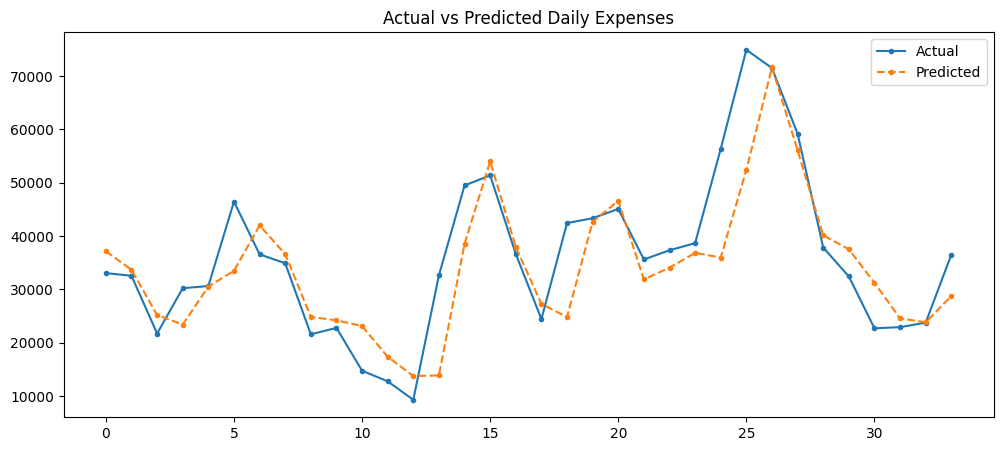

In [ ]:
val_loss_ts, val_mae_ts = forecast_model.evaluate(val_ds_ts, verbose=0)
print(f'\n✅ Validation MAE Akhir: {val_mae_ts:.4f}')

y_pred_ts = forecast_model.predict(X_val_ts)
y_val_actual = scaler_forecast.inverse_transform(y_val_ts)
y_pred_actual = scaler_forecast.inverse_transform(y_pred_ts)

mae_rupiah = np.mean(np.abs(y_val_actual - y_pred_actual))
print(f'💰 MAE dalam Rupiah: Rp {mae_rupiah:,.2f}')

# Plot Prediksi
plt.figure(figsize=(12, 5))
plt.plot(y_val_actual, label='Actual', marker='.')
plt.plot(y_pred_actual, label='Predicted', linestyle='--', marker='.')
plt.legend()
plt.title('Actual vs Predicted Daily Expenses')
plt.show()

In [ ]:
EXPORT_DIR = 'saved_models'
os.makedirs(EXPORT_DIR, exist_ok=True)

classifier_model.save(os.path.join(EXPORT_DIR, 'classifier_model.keras'))
forecast_model.save(os.path.join(EXPORT_DIR, 'forecasting_model.keras'))

with open(os.path.join(EXPORT_DIR, 'label_encoder.pkl'), 'wb') as f: pickle.dump(label_encoder, f)
with open(os.path.join(EXPORT_DIR, 'scaler_classifier.pkl'), 'wb') as f: pickle.dump(scaler_classifier, f)
with open(os.path.join(EXPORT_DIR, 'scaler_forecast.pkl'), 'wb') as f: pickle.dump(scaler_forecast, f)

import json as json_lib
metadata = {
    'classifier': {'accuracy': float(val_acc)},
    'forecaster': {'mae': float(val_mae_ts), 'window_size': WINDOW_SIZE}
}
with open(os.path.join(EXPORT_DIR, 'model_metadata.json'), 'w') as f: json_lib.dump(metadata, f, indent=2)

import shutil
shutil.make_archive('arthawise_models', 'zip', '.', EXPORT_DIR)
files.download('arthawise_models.zip')
print("📦 Download model siap!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📦 Download model siap!


In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf # Import tensorflow for tf.constant

# FUNGSI 1: Prediksi kategori transaksi (Classifier)
def predict_category(title: str, amount: float, tipe: str) -> dict:
    tipe = tipe.upper()
    if tipe not in ('EXPENSE', 'INCOME'):
        raise ValueError("tipe harus 'EXPENSE' atau 'INCOME'")

    # Explicitly convert to a TensorFlow string tensor
    text_input_tensor = tf.constant([title], dtype=tf.string)
    amount_scaled = scaler_classifier.transform([[amount]])
    type_encoded  = np.array([[1.0 if tipe == 'INCOME' else 0.0]])
    numeric_input = np.hstack([amount_scaled, type_encoded]).astype('float32')

    probs      = classifier_model.predict(
        {'text_input': text_input_tensor, 'numeric_input': numeric_input}, verbose=0
    )[0]
    pred_idx   = np.argmax(probs)
    pred_label = label_encoder.classes_[pred_idx]
    pred_conf  = probs[pred_idx]

    confidence_all = {
        label_encoder.classes_[i]: round(float(probs[i]) * 100, 2)
        for i in range(len(probs))
    }
    return {
        'prediksi'   : pred_label,
        'confidence' : f'{pred_conf * 100:.2f}%',
        'semua_kelas': confidence_all,
    }

# FUNGSI 2: Prediksi pengeluaran harian besok (Forecaster)
def predict_pengeluaran_besok(pengeluaran_14_hari: list) -> dict:
    if len(pengeluaran_14_hari) != 14:
        raise ValueError(f'Butuh tepat 14 nilai, diberikan {len(pengeluaran_14_hari)} diffused.')

    arr      = np.array(pengeluaran_14_hari, dtype=float)
    smoothed = np.array([arr[max(0, i-2):i+1].mean() for i in range(len(arr))])
    scaled   = scaler_forecast.transform(smoothed.reshape(-1, 1))
    X_input  = scaled.reshape(1, 14, 1)

    pred_scaled = forecast_model.predict(X_input, verbose=0)
    pred_rupiah = scaler_forecast.inverse_transform(pred_scaled)[0][0]

    return {
        'prediksi_besok_rp' : round(pred_rupiah, 2),
        'prediksi_besok_fmt': f'Rp {pred_rupiah:,.0f}',
        'rata_rata_14_hari' : f'Rp {np.mean(pengeluaran_14_hari):,.0f}',
    }


# Classifier: satu transaksi
result = predict_category('Warung Nasi', 25000, 'EXPENSE')
print(f"Prediksi : {result['prediksi']}")
print(f"Confidence : {result['confidence']}")
print("Skor semua kelas:")
for k, v in sorted(result['semua_kelas'].items(), key=lambda x: -x[1]):
    print(f"  {k:<15} {'█' * int(v/5):<20} {v:.2f}%")

print()

# Classifier: batch transaksi
transaksi_baru = [
    {'title': 'Warung Nasi',   'amount': 25000,   'tipe': 'EXPENSE'},
    {'title': 'Netflix',       'amount': 54000,   'tipe': 'EXPENSE'},
    {'title': 'Gaji Bulanan',  'amount': 5000000, 'tipe': 'INCOME'},
    {'title': 'Listrik PLN',   'amount': 150000,  'tipe': 'EXPENSE'},
    {'title': 'Sepatu Baru',   'amount': 350000,  'tipe': 'EXPENSE'},
    {'title': 'Tabungan Dana', 'amount': 500000,  'tipe': 'EXPENSE'},
]
rows = []
for t in transaksi_baru:
    r = predict_category(t['title'], t['amount'], t['tipe'])
    rows.append({'Title': t['title'], 'Amount': t['amount'],
                 'Type': t['tipe'], 'Kategori': r['prediksi'],
                 'Confidence': r['confidence']})
display(pd.DataFrame(rows))

print()

# --- Forecaster: dari 14 hari terakhir di dataset ---
df_exp = df[df['Type'] == 'EXPENSE'].copy()
df_exp['Date'] = pd.to_datetime(df_exp['Date'])
daily = df_exp.groupby('Date')['Amount'].sum().sort_index()
last_14 = daily.values[-14:].tolist()

print("14 hari terakhir:")
for i, (d, v) in enumerate(zip(daily.index[-14:], last_14), 1):
    print(f"  {i:2}. {str(d)[:10]}  Rp {v:>12,.0f}")

hasil = predict_pengeluaran_besok(last_14)
print()
print('=' * 40)
print('  PREDIKSI PENGELUARAN BESOK')
print('=' * 40)
print(f"  Prediksi  : {hasil['prediksi_besok_fmt']}")
print(f"  Rata-rata : {hasil['rata_rata_14_hari']}")
print('=' * 40)

Prediksi : Makan & Minum
Confidence : 75.64%
Skor semua kelas:
  Makan & Minum   ███████████████      75.64%
  Belanja         ██                   11.05%
  Tagihan         ██                   10.42%
  Goals                                1.27%
  Gaji                                 0.96%
  Hiburan                              0.65%



,Title,Amount,Type,Kategori,Confidence
0,Warung Nasi,25000,EXPENSE,Makan & Minum,75.64%
1,Netflix,54000,EXPENSE,Tagihan,24.88%
2,Gaji Bulanan,5000000,INCOME,Gaji,73.01%
3,Listrik PLN,150000,EXPENSE,Tagihan,43.04%
4,Sepatu Baru,350000,EXPENSE,Goals,34.95%
5,Tabungan Dana,500000,EXPENSE,Goals,63.75%



14 hari terakhir:
   1. 2025-12-18  Rp       37,293
   2. 2025-12-19  Rp       36,555
   3. 2025-12-20  Rp       38,154
   4. 2025-12-21  Rp       41,249
   5. 2025-12-22  Rp       89,682
   6. 2025-12-23  Rp       93,831
   7. 2025-12-24  Rp       30,950
   8. 2025-12-25  Rp       52,691
   9. 2025-12-26  Rp       29,888
  10. 2025-12-27  Rp       14,657
  11. 2025-12-28  Rp       23,532
  12. 2025-12-29  Rp       30,543
  13. 2025-12-30  Rp       17,192
  14. 2025-12-31  Rp       61,759

  PREDIKSI PENGELUARAN BESOK
  Prediksi  : Rp 38,014
  Rata-rata : Rp 42,713
